In [1]:
import pandas as pd 
import numpy as np
from xgboost import XGBClassifier,plot_importance
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,accuracy_score
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("HR_Employee_Attrition.csv")

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [10]:
for i in df.columns:
    unique=df[i].unique()
    if len(unique)==1:
        df.drop(columns=[i],inplace=True)
    elif len(unique)==len(df["Age"]):
        df.drop(columns=[i],inplace=True)
#It removes all columns where all rows contain a single value or where each row has a unique value.


In [11]:
df.dropna(inplace=True)

In [12]:
lr=LabelEncoder()

In [13]:
for i in df.columns:
    if df[i].dtype ==object:
        df[i]=lr.fit_transform(df[i])

In [14]:
x=df.drop(columns=["Attrition"])
y=df["Attrition"]

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [16]:
line=LinearRegression()
line.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
pred_line_r=line.predict(x_train)
print("According to training data R2 Scorec :",r2_score(y_train,pred_line_r))

According to training data R2 Scorec : 0.20763159286593302


In [18]:
pred_line=line.predict(x_test)
print("According to testing data R2 Score :",r2_score(y_test,pred_line))

According to testing data R2 Score : 0.21018694837732488


In [19]:
dt=DecisionTreeClassifier(max_depth=3)
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:

pred_decision_r=dt.predict(x_train)
print("According to training data Accuracy Score :",accuracy_score(y_train,pred_decision_r))

According to training data Accuracy Score : 0.8668610301263362


In [21]:
pred_decision=dt.predict(x_test)
print("According to testing data Accuracy Score :",accuracy_score(y_test,pred_decision))

According to testing data Accuracy Score : 0.8344671201814059


In [22]:
log=LogisticRegression()
log.fit(x_train,y_train)

c:\Users\RAVI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
pred_log=log.predict(x_train)
print("According to training data Accuracy Score :",accuracy_score(y_train,pred_log))

According to training data Accuracy Score : 0.8415937803692906


In [24]:
pred_log=log.predict(x_test)
print("According to testing data Accuracy Score :",accuracy_score(y_test,pred_log))

According to testing data Accuracy Score : 0.8435374149659864


In [25]:
xgb=XGBClassifier(max_depth=1)
xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [26]:
pred_xgb=xgb.predict(x_train)
print("According to training data Accuracy Score :",accuracy_score(y_train,pred_xgb))


According to training data Accuracy Score : 0.8901846452866861


In [27]:
pred_xgb=xgb.predict(x_test)
print("According to testing data Accuracy Score :",accuracy_score(y_test,pred_xgb))

According to testing data Accuracy Score : 0.8956916099773242


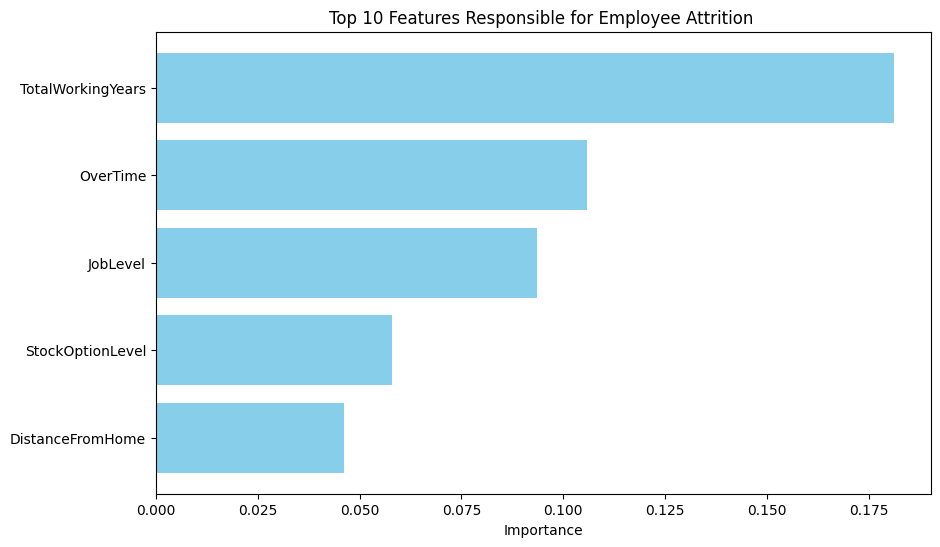

In [28]:
importances=xgb.feature_importances_
features=x.columns

indices = np.argsort(importances)[::-1]  
sorted_features = features[indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10,6))
plt.barh(range(len(sorted_importances[:5])), sorted_importances[:5][::-1], color='skyblue')  
plt.yticks(range(len(sorted_features[:5])), sorted_features[:5][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Features Responsible for Employee Attrition ')
plt.show()


In [29]:
def prediction():
    Age=int(input("Enter your age : "))
    BusinessTravel=int(input("Enter Business Travel ( Non-Travel:-0, Travel_Frequently:-1 Travel_Rarely:-2) :"))
    DailyRate=int(input("Enter DailyRate (100-1500) : "))
    Department=int(input("Enter Department (Human Resources:-0, Research & Development:- 1, Sales:-2) :"))
    DistanceFromHome=int(input("Enter Distance From Home (1-30) :"))
    Education=int(input("Enter Education (1-5) : "))
    EducationField=int(input("Enter Education Field (Human Resources:-0, Life Sciences:-1, Marketing:-2, Medical:-3, Other:-4,Technical Degree:-5) : "))
    EnvironmentSatisfaction=int(input("Enter Environment Satisfaction (1-4) : "))
    Gender=int(input("Enter Gender (Female:-0, Male:-1) : "))
    HourlyRate=int(input("Enter Hourly Rate (30-100)"))
    JobInvolvement=int(input("Enter Job Involvement (1-4) : "))
    JobLevel=int(input("Enter Job level (1-5) : "))
    JobRole=int(input("Enter Job Role (Healthcare Representative:-0, Human Resources:-1, Laboratory Technician:-2, Manager:-3, Manufacturing Director:-4, Research Director:-5, Research Scientist:-6, Sales Executive:-7, Sales Representative:-8) : "))
    JobSatisfaction=int(input("Enter Job Satisfaction (1-4) : "))
    MaritalStatus=int(input("Enter Marital Status (Divorced:-0, Married:-1, Single:-2) : "))
    MonthlyIncome=int(input("Enter Monthly Income (1000-20000) : "))
    MonthlyRate=int(input("Enter Monthly Rate (2000-27000) : "))
    NumCompaniesWorked=int(input("Enter Number Companies Worked (0-9) : "))
    OverTime=int(input("Enter Overtime (No:-0, Yes:-1) : "))
    PercentSalaryHike=int(input("Enter Percent Salary Hike (11-25) : "))
    PerformanceRating=int(input("Enter Performance Rating (3-4) : "))
    RelationshipSatisfaction=int(input("Enter Relationship Satisfaction (1-4) : "))
    StockOptionLevel=int(input("Enter Stock Option Level (0-3) : "))
    TotalWorkingYears=int(input("Enter Total Working Years (0-40) : "))
    TrainingTimesLastYear=int(input("Enter Training Times Last Year (0-6) : "))
    WorkLifeBalance=int(input("Enter Work Life Balance (1-4) : "))
    YearsAtCompany=int(input("Enter Years At Company (0-40) : "))
    YearsInCurrentRole=int(input("Enter Years In Current Role (0-20) : "))
    YearsSinceLastPromotion=int(input("Enter Years Since Last Promotion (0-15) : "))
    YearsWithCurrManager=int(input("Enter Years With Current Manager (0-17)"))
    x=[[Age, BusinessTravel, DailyRate, Department, DistanceFromHome,Education,
       EducationField, EnvironmentSatisfaction, Gender,HourlyRate, JobInvolvement,
       JobLevel, JobRole, JobSatisfaction, MaritalStatus, MonthlyIncome, MonthlyRate,
       NumCompaniesWorked, OverTime, PercentSalaryHike,
       PerformanceRating, RelationshipSatisfaction, StockOptionLevel,
       TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance,
       YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion,
       YearsWithCurrManager]]
    final_result=xgb.predict(x)
    return final_result
result=prediction()


In [ ]:
if result==0:
    print("He/She can work for few years")
else:
    print("He/she can leave anytime ")

He/She can work for few years
